# SIGNAL PROCESSING TUTORIAL
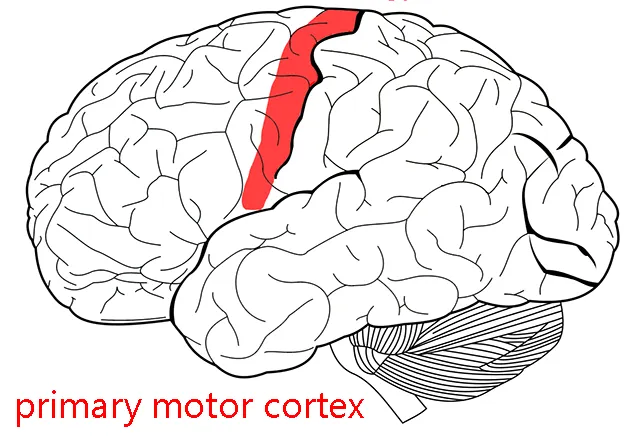
> Right-Hemisphere M1 Hand Knob


## Topics covered

  0.  Imports & data loading
  1.  Resampling / decimation
  2.  Linear filtering: IIR Butterworth (low-pass, high-pass, band-pass)
  3.  Linear filtering: FIR (firwin / window design)
  4.  filtfilt vs lfilter: phase delay demo + Gustafsson's edge method
  5.  Non-linear filtering: Median & Savitzky-Golay
  6.  Convolution for time-series (box, Hanning, Gaussian, derivative kernels)
  7.  Z-score normalisation
  8. Power Spectral Density: Welch's method
  9. Spectrogram computation





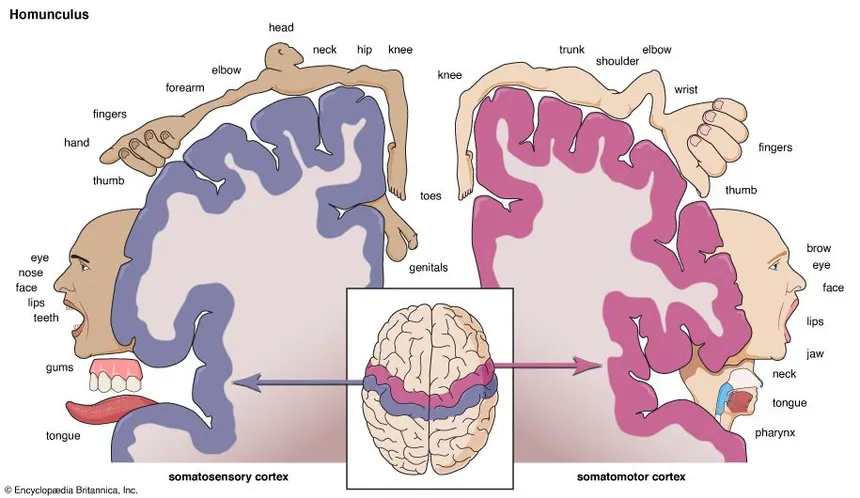

In [97]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — IMPORTS & DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.ndimage import median_filter
from pathlib import Path
import warnings
import timeit

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.autolayout': True,
})

# ── Configuration ──────────────────────────────────────────────────────────────
DATA_DIR  = Path("./extracted_raw_time_series")
ORIG_FS   = 500.0   # original sampling rate from LCMV pipeline (Hz)
TARGET_FS = 250.0   # target after decimation (Hz)

# ── Load data ─────────────────────────────────────────────────────────────────
rest_raw = np.load(DATA_DIR / "R_M1_hand_knob_voxel_EyesClosed_Rest.npy")
move_raw = np.load(DATA_DIR / "R_M1_hand_knob_voxel_LeftHand_Move.npy")

In [98]:
# ── Print info ───────────────────────────────────────────────────────────────

print("=" * 50)
print("M1 Hand-Knob Signal Processing Tutorial")
print("=" * 50)
print(f"Rest: {len(rest_raw)} samples, {len(rest_raw)/500:.1f} seconds")
print(f"Move: {len(move_raw)} samples, {len(move_raw)/500:.1f} seconds")

M1 Hand-Knob Signal Processing Tutorial
Rest: 7500 samples, 15.0 seconds
Move: 7500 samples, 15.0 seconds


In [100]:
rest_raw.shape[0]/ORIG_FS # = time series duration (seconds)

15.0

In [101]:
ORIG_FS*15 # = number of samples

7500.0

In [102]:
rest_raw.shape[0]/15 # = sampling rate (points/second)

500.0

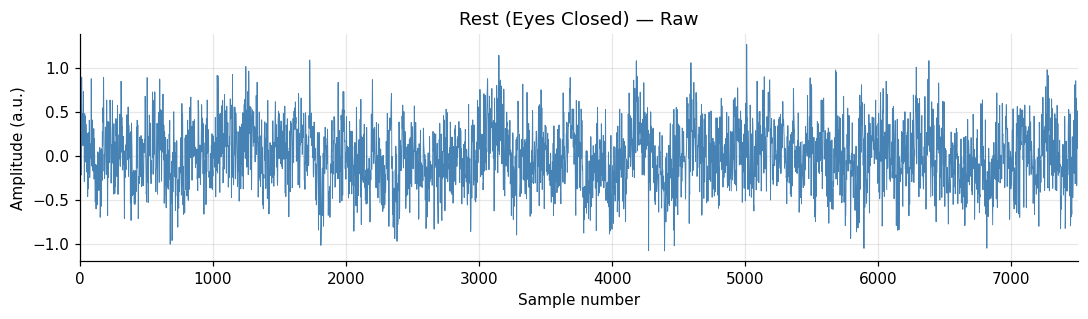

In [103]:
# ── Plot 1: Rest ─────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 3))
plt.plot(rest_raw, lw=0.6, color='steelblue')
plt.xlim(0, len(rest_raw))
plt.title("Rest (Eyes Closed) — Raw")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

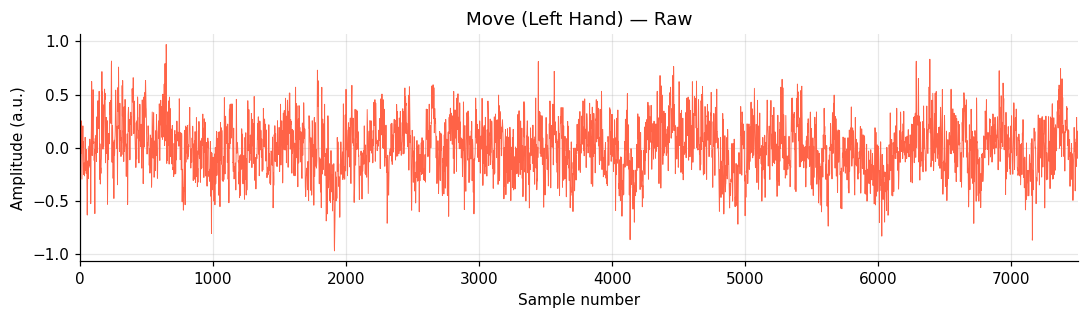

In [104]:
# ── Plot 2: Move ─────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 3))
plt.plot(move_raw, lw=0.6, color='tomato')
plt.xlim(0, len(move_raw))
plt.title("Move (Left Hand) — Raw")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

## SECTION 1: RESAMPLING (DECIMATION)

**Resample:**
  500 Hz → 250 Hz halves data size. Nyquist at 250 Hz = 125 Hz, well above our analysis band (1–45 Hz).

Aliasing: naively dropping every other sample folds high-freq content down.

> scipy.signal.decimate applies an anti-aliasing LPF *before* subsampling.
> zero_phase=True  → no event-time shift

The `scipy.signal.decimate` function is used to **downsample a signal by an integer factor** after applying an anti-aliasing lowpass filter to prevent distortion. By default, it uses an **order 8 Chebyshev Type I IIR filter**, but can also use a **30-point FIR filter** with a Hamming window if `ftype='fir'` is specified.

Key parameters include:
*   **`x`**: The input signal array.
*   **`q`**: The downsampling factor (integer). For factors greater than 13, it is recommended to call the function multiple times.
*   **`n`**: The filter order, defaulting to 8 for IIR and 20 times `q` for FIR.
*   **`ftype`**: Specifies the filter type (`'iir'` or `'fir'`).
*   **`zero_phase`**: When `True` (default in recent versions), it prevents phase shift by filtering in both directions (IIR) or shifting outputs (FIR).



In [105]:
q         = int(ORIG_FS / TARGET_FS)   # downsampling factor = 2
rest_dec  = signal.decimate(rest_raw, q, ftype='iir', zero_phase=True)
move_dec  = signal.decimate(move_raw, q, ftype='iir', zero_phase=True)

print(f"\n[Decimation]  {rest_raw.shape[0]} samples @ {int(ORIG_FS)} Hz  →  "
      f"{rest_dec.shape[0]} samples @ {int(TARGET_FS)} Hz  (q={q})")



[Decimation]  7500 samples @ 500 Hz  →  3750 samples @ 250 Hz  (q=2)


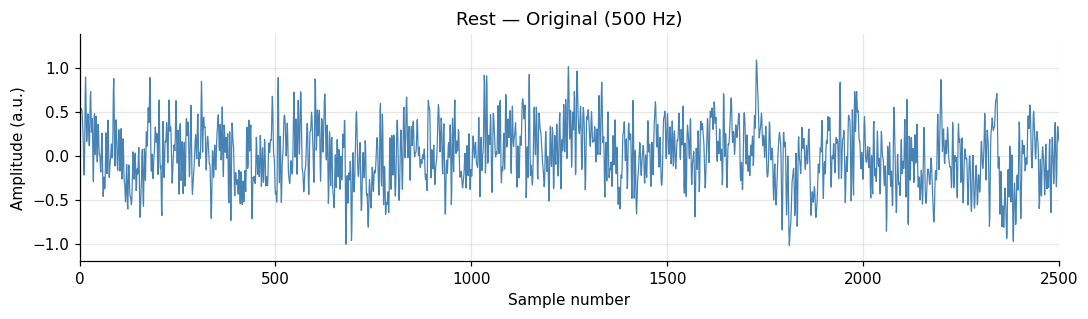

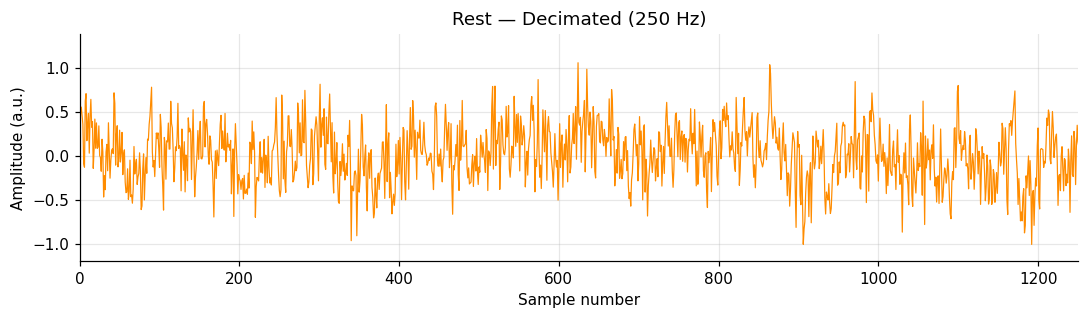

In [106]:
# ── 1. Rest: Original (500 Hz) ───────────────────────────────────────────────

plt.figure(figsize=(10, 3))
plt.plot(rest_raw, lw=0.8, color='steelblue')
plt.xlim(0, 2500)          # first 5 seconds (5 × 500 = 2500 samples)
plt.title("Rest — Original (500 Hz)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

# ── 2. Rest: Decimated (250 Hz) ──────────────────────────────────────────────

plt.figure(figsize=(10, 3))
plt.plot(rest_dec, lw=0.8, color='darkorange')
plt.xlim(0, 1250)          # first 5 seconds (5 × 250 = 1250 samples)
plt.title("Rest — Decimated (250 Hz)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

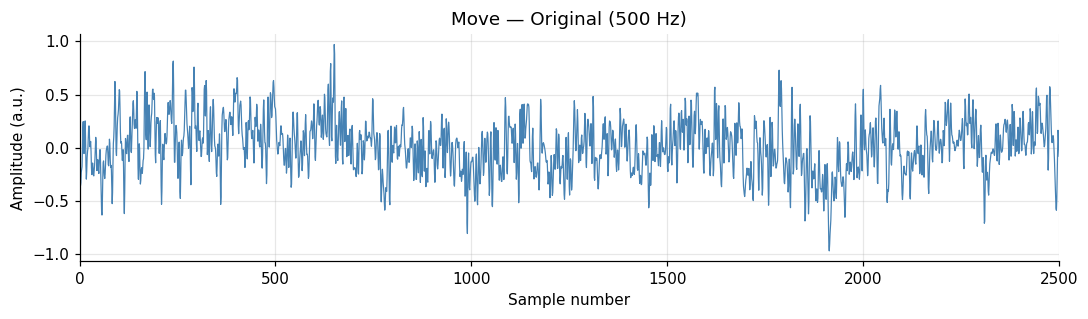

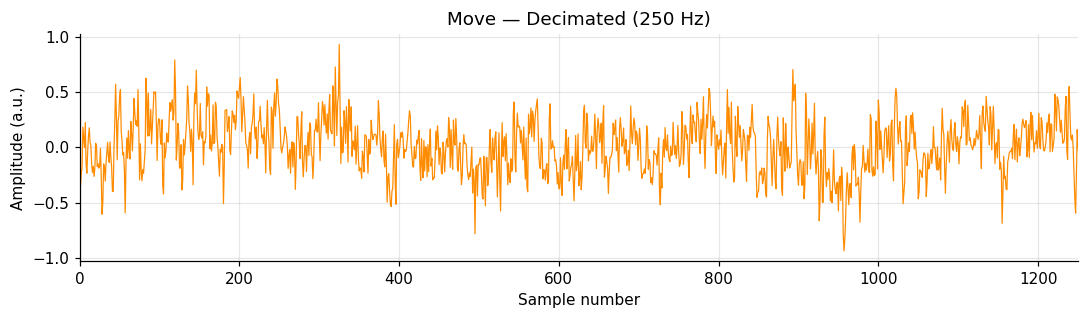

In [107]:
# ── 3. Move: Original (500 Hz) ───────────────────────────────────────────────

plt.figure(figsize=(10, 3))
plt.plot(move_raw, lw=0.8, color='steelblue')
plt.xlim(0, 2500)
plt.title("Move — Original (500 Hz)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

# ── 4. Move: Decimated (250 Hz) ──────────────────────────────────────────────

plt.figure(figsize=(10, 3))
plt.plot(move_dec, lw=0.8, color='darkorange')
plt.xlim(0, 1250)
plt.title("Move — Decimated (250 Hz)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (a.u.)")
plt.tight_layout()
plt.show()

## SECTION 2: LINEAR FILTERING: IIR BUTTERWORTH

- IIR = Infinite Impulse Response, uses feedback (poles).
- Butterworth: maximally flat passband ("no ripple").
- SOS (Second-Order Sections) form is numerically stable for high orders.



In [108]:
x = rest_dec   # the signal we're filtering (3750 samples at 250 Hz)

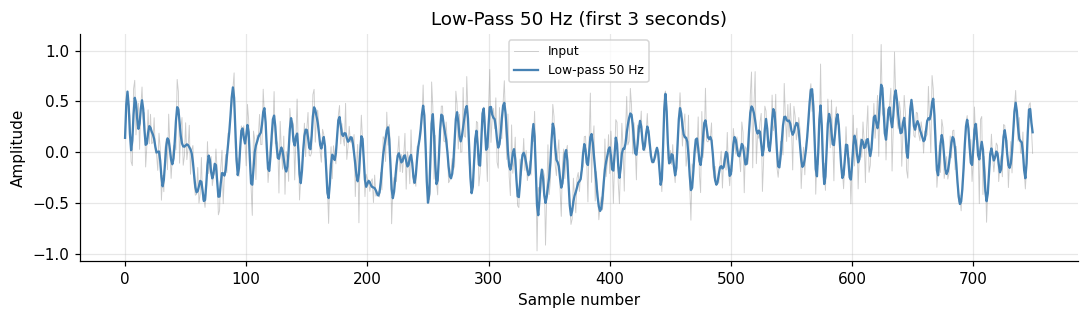

In [109]:
# ── Low-pass 50 Hz ───────────────────────────────────────────────────────────

nyq = 0.5 * 250                           # Nyquist = 125 Hz
wn = 50.0 / nyq                           # 50/125 = 0.4
sos = signal.butter(4, wn, btype='lowpass', output='sos')
lp = signal.sosfiltfilt(sos, x)

plt.figure(figsize=(10, 3))
plt.plot(x[:750],  lw=0.6, alpha=0.4, color='gray', label='Input')
plt.plot(lp[:750], lw=1.5, color='steelblue',       label='Low-pass 50 Hz')
plt.title("Low-Pass 50 Hz (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


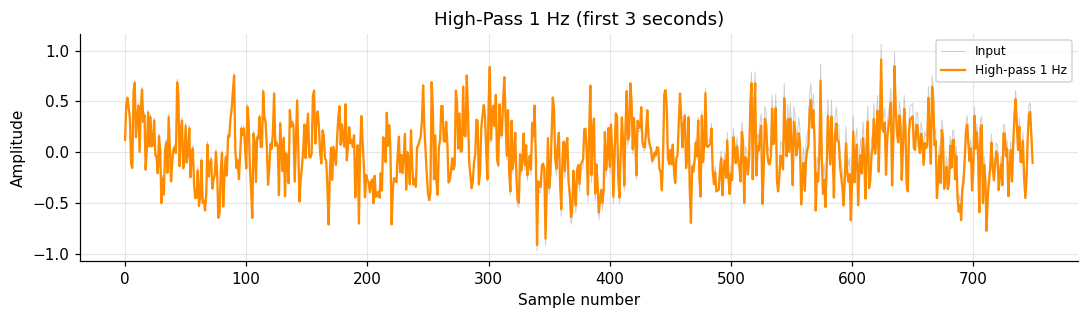

In [110]:
# ── High-pass 1 Hz ───────────────────────────────────────────────────────────

wn = 1.0 / nyq                            # 1/125 = 0.008
sos = signal.butter(4, wn, btype='highpass', output='sos')
hp = signal.sosfiltfilt(sos, x)

plt.figure(figsize=(10, 3))
plt.plot(x[:750],  lw=0.6, alpha=0.4, color='gray', label='Input')
plt.plot(hp[:750], lw=1.5, color='darkorange',      label='High-pass 1 Hz')
plt.title("High-Pass 1 Hz (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

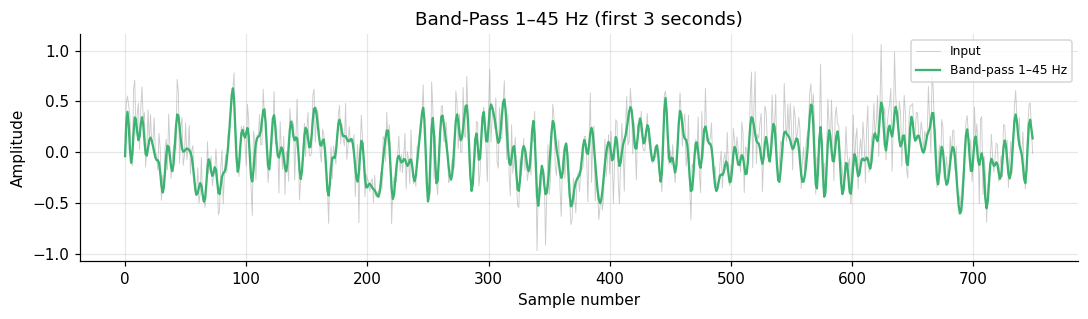

In [111]:
# ── Band-pass 1–45 Hz ────────────────────────────────────────────────────────

wn = [1.0/nyq, 45.0/nyq]                 # [0.008, 0.36]
sos = signal.butter(4, wn, btype='bandpass', output='sos')
bp = signal.sosfiltfilt(sos, x)

plt.figure(figsize=(10, 3))
plt.plot(x[:750],  lw=0.6, alpha=0.4, color='gray', label='Input')
plt.plot(bp[:750], lw=1.5, color='mediumseagreen',  label='Band-pass 1–45 Hz')
plt.title("Band-Pass 1–45 Hz (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

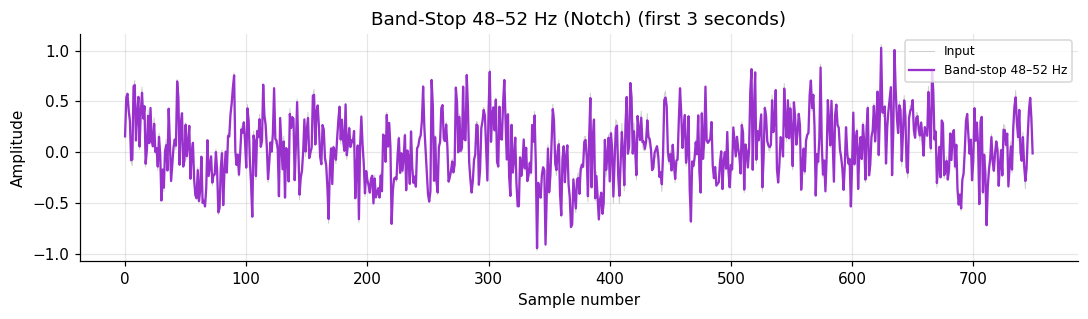

In [112]:
# ── Band-stop 48–52 Hz (Notch) ───────────────────────────────────────────────

wn = [48.0/nyq, 52.0/nyq]                # [0.384, 0.416]
sos = signal.butter(4, wn, btype='bandstop', output='sos')
bs = signal.sosfiltfilt(sos, x)

plt.figure(figsize=(10, 3))
plt.plot(x[:750],  lw=0.6, alpha=0.4, color='gray', label='Input')
plt.plot(bs[:750], lw=1.5, color='darkorchid',      label='Band-stop 48–52 Hz')
plt.title("Band-Stop 48–52 Hz (Notch) (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

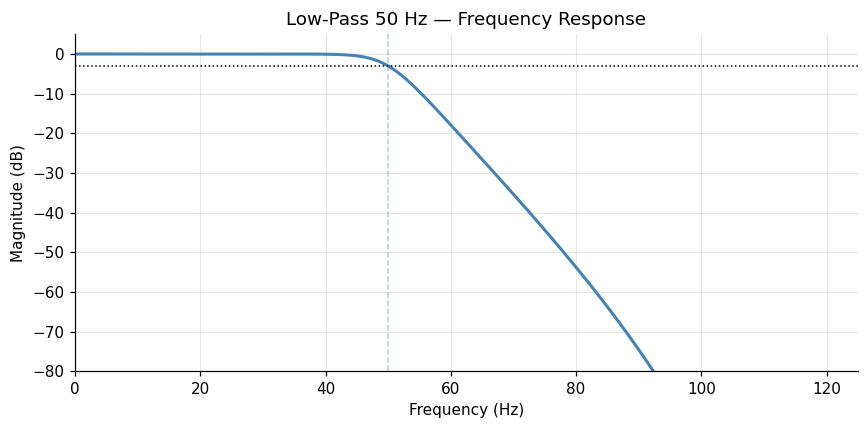

In [113]:
# Low-Pass 50 Hz

nyq = 125                              # Nyquist = half sampling rate (250/2)
wn = 50.0 / nyq                        # Normalized cutoff: 50 Hz → 0.4
sos = signal.butter(8, wn, btype='lowpass', output='sos')  # Design filter
w, h = signal.sosfreqz(sos, worN=2048, fs=250)            # Test filter

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='steelblue')
plt.axhline(-3, color='black', ls=':', lw=1)         # -3 dB cutoff reference
plt.axvline(50, color='steelblue', ls='--', lw=1, alpha=0.4)  # 50 Hz marker
plt.xlim(0, 125)
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Low-Pass 50 Hz — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

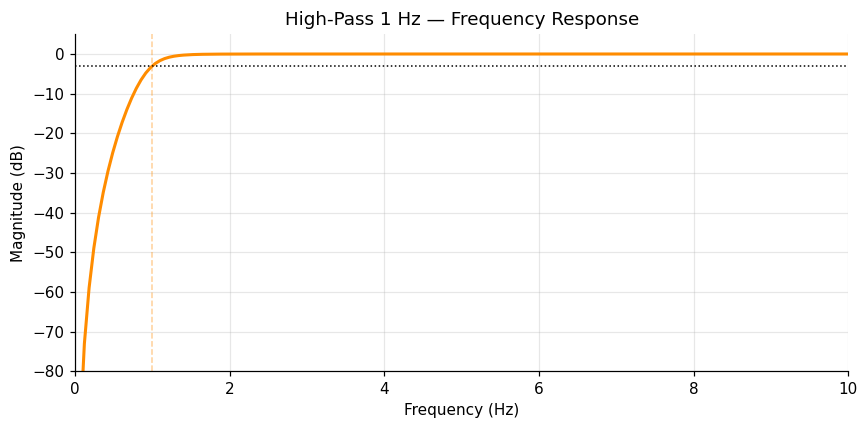

In [114]:
# High-Pass 1 Hz

wn = 1.0 / nyq                         # Normalized cutoff: 1 Hz → 0.008
sos = signal.butter(4, wn, btype='highpass', output='sos')
w, h = signal.sosfreqz(sos, worN=2048, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='darkorange')
plt.axhline(-3, color='black', ls=':', lw=1)
plt.axvline(1, color='darkorange', ls='--', lw=1, alpha=0.4)
plt.xlim(0, 10)                        # Zoomed: nothing interesting above 10 Hz
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("High-Pass 1 Hz — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

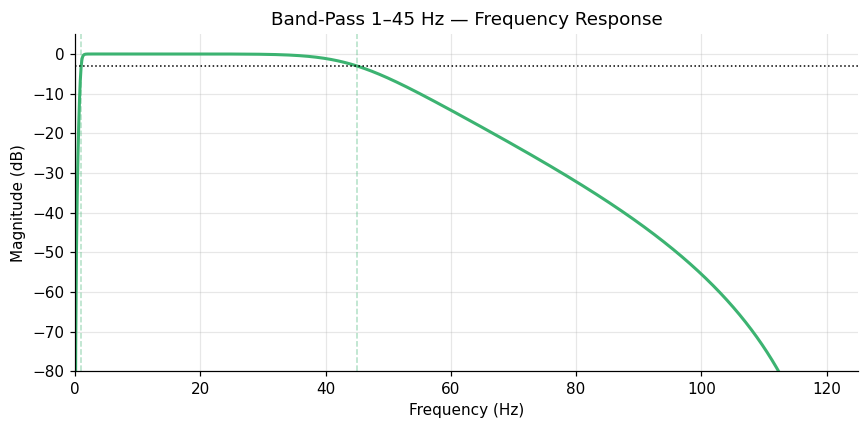

In [115]:
# Band-Pass 1–45 Hz

wn = [1.0/nyq, 45.0/nyq]               # Two cutoffs: [0.008, 0.36]
sos = signal.butter(4, wn, btype='bandpass', output='sos')
w, h = signal.sosfreqz(sos, worN=2048, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='mediumseagreen')
plt.axhline(-3, color='black', ls=':', lw=1)
plt.axvline(1, color='mediumseagreen', ls='--', lw=1, alpha=0.4)
plt.axvline(45, color='mediumseagreen', ls='--', lw=1, alpha=0.4)
plt.xlim(0, 125)
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Band-Pass 1–45 Hz — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

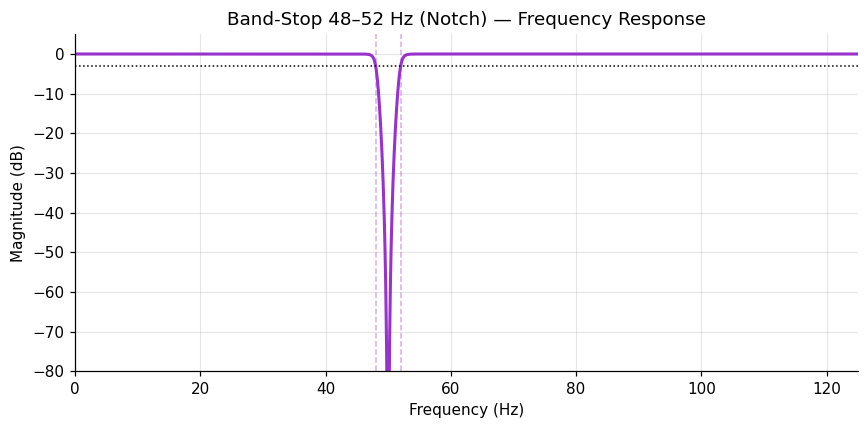

In [116]:
# Band-Stop 48–52 Hz (Notch)

wn = [48.0/nyq, 52.0/nyq]              # Two cutoffs: [0.384, 0.416]
sos = signal.butter(4, wn, btype='bandstop', output='sos')
w, h = signal.sosfreqz(sos, worN=2048, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='darkorchid')
plt.axhline(-3, color='black', ls=':', lw=1)
plt.axvline(48, color='darkorchid', ls='--', lw=1, alpha=0.4)
plt.axvline(52, color='darkorchid', ls='--', lw=1, alpha=0.4)
plt.xlim(0, 125)
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Band-Stop 48–52 Hz (Notch) — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SECTION 3: LINEAR FILTERING: FIR (WINDOW DESIGN)

- FIR = Finite Impulse Response, no feedback, always stable.
- Window design (firwin): choose a window shape to control stop-band roll-off.

### Window trade-offs:
- Rectangular: sharpest transition, worst side-lobes
- Hann / Hanning: good general purpose
- Kaiser(β): tunable, higher β → more attenuation, wider transition band
- Blackman: excellent attenuation, moderate transition width

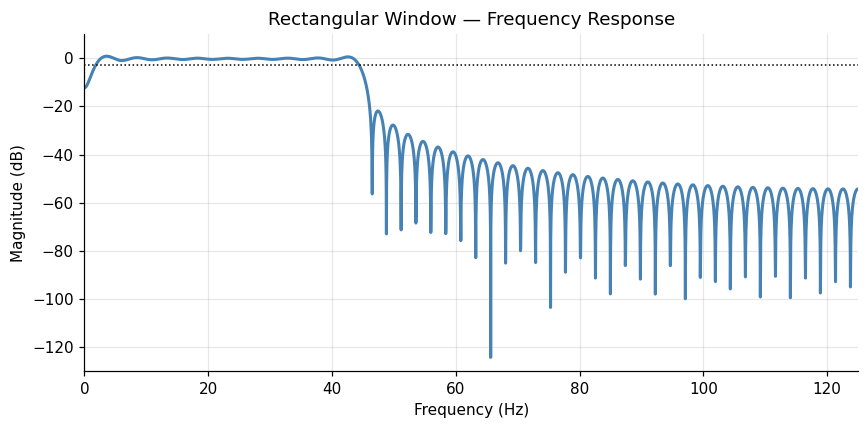

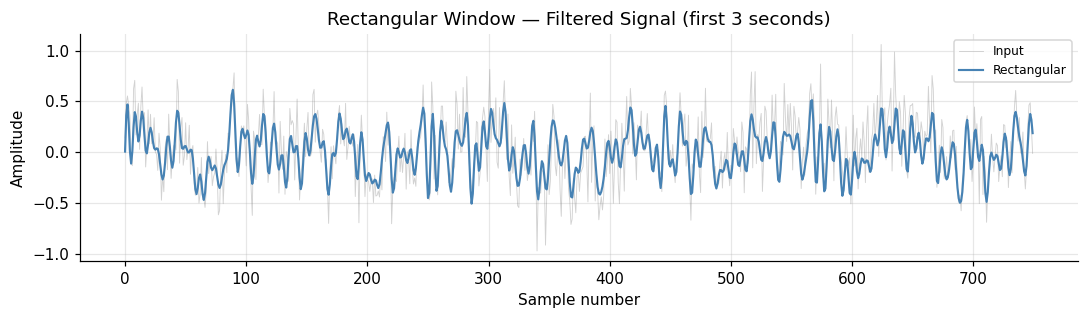

In [117]:
# ═══════════════════════════════════════════════════════════════════════════════
# RECTANGULAR WINDOW — FIR Band-Pass 1–45 Hz
# ═══════════════════════════════════════════════════════════════════════════════
# FIR filter designed with firwin(). Window shape affects how sharply the filter
# cuts off vs how much ripple appears in the stopband.
# Rectangular = no window (abrupt cut at edges). Sharpest transition, worst ripple.

numtaps = 101                                      # filter length (odd → linear phase)
cutoff = [1.0/125, 45.0/125]                       # band-pass [0.008, 0.36]

# ── Design the filter ────────────────────────────────────────────────────────
taps = signal.firwin(numtaps, cutoff, pass_zero=False, window='rectangular')
# taps = 101 weights. These ARE the filter.  a=1.0 means no feedback (FIR).

# ── Frequency response ───────────────────────────────────────────────────────
w, h = signal.freqz(taps, 1.0, worN=4096, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='steelblue')
plt.axhline(-3, color='black', ls=':', lw=1)       # -3 dB cutoff reference
plt.xlim(0, 125)
plt.ylim(-130, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Rectangular Window — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Apply filter to signal ───────────────────────────────────────────────────
y_fir = signal.filtfilt(taps, 1.0, rest_dec)       # forward+backward → zero phase

plt.figure(figsize=(10, 3))
plt.plot(rest_dec[:750], lw=0.6, alpha=0.35, color='gray', label='Input')
plt.plot(y_fir[:750],    lw=1.4, color='steelblue', label='Rectangular')
plt.title("Rectangular Window — Filtered Signal (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

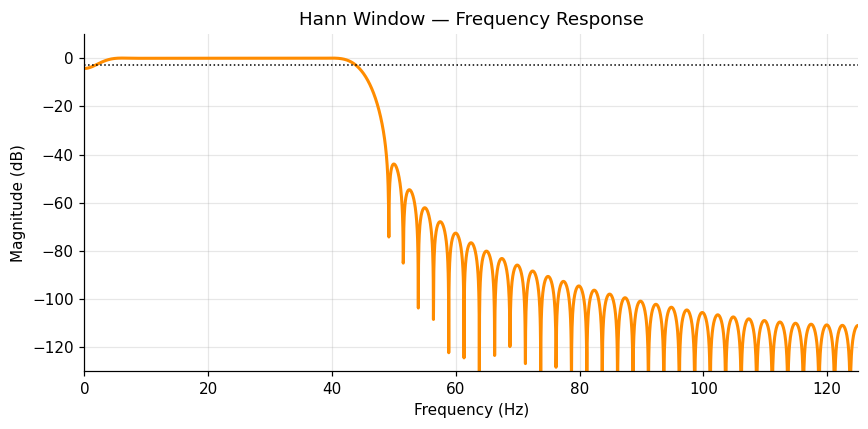

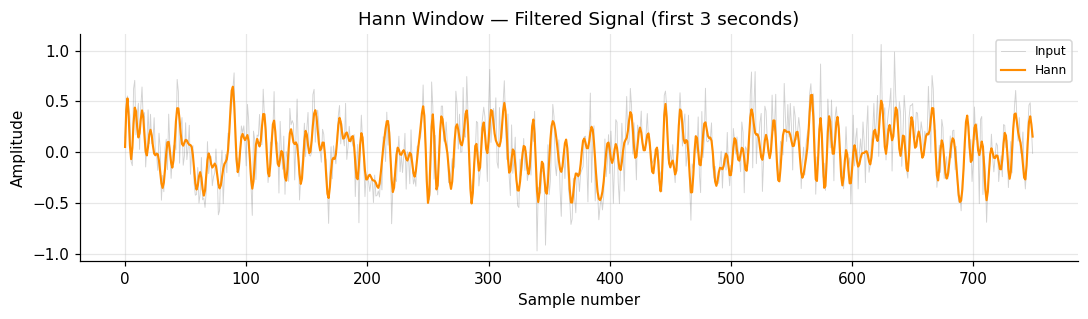

In [118]:
# ═══════════════════════════════════════════════════════════════════════════════
# HANN WINDOW — FIR Band-Pass 1–45 Hz
# ═══════════════════════════════════════════════════════════════════════════════
# Hann window = smooth bell curve. Good general-purpose. Smooth stopband,
# moderate transition width.

numtaps = 101
cutoff = [1.0/125, 45.0/125]

# ── Design the filter ────────────────────────────────────────────────────────
taps = signal.firwin(numtaps, cutoff, pass_zero=False, window='hann')

# ── Frequency response ───────────────────────────────────────────────────────
w, h = signal.freqz(taps, 1.0, worN=4096, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='darkorange')
plt.axhline(-3, color='black', ls=':', lw=1)
plt.xlim(0, 125)
plt.ylim(-130, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Hann Window — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Apply filter to signal ───────────────────────────────────────────────────
y_fir = signal.filtfilt(taps, 1.0, rest_dec)

plt.figure(figsize=(10, 3))
plt.plot(rest_dec[:750], lw=0.6, alpha=0.35, color='gray', label='Input')
plt.plot(y_fir[:750],    lw=1.4, color='darkorange', label='Hann')
plt.title("Hann Window — Filtered Signal (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

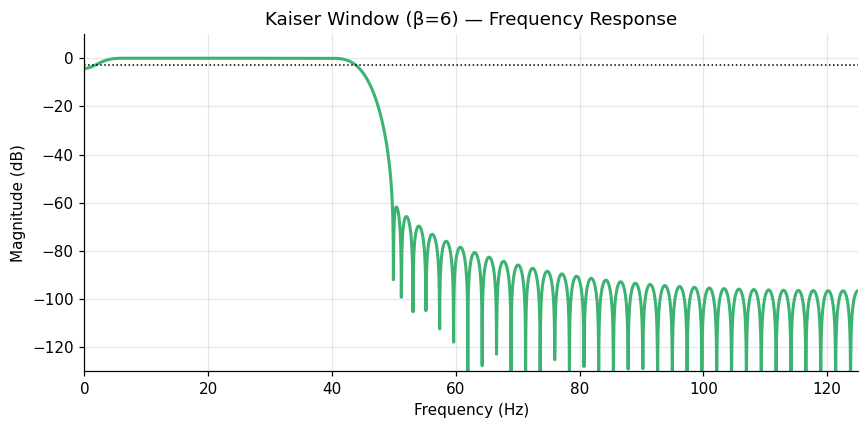

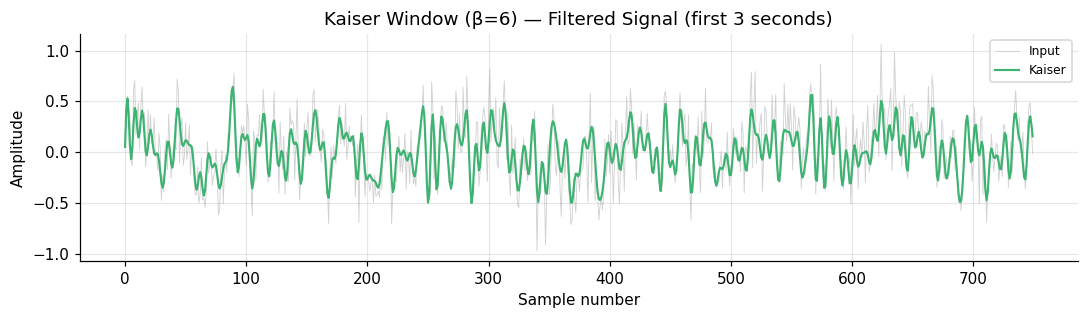

In [119]:
# ═══════════════════════════════════════════════════════════════════════════════
# KAISER WINDOW (β=6) — FIR Band-Pass 1–45 Hz
# ═══════════════════════════════════════════════════════════════════════════════
# Kaiser window = tunable with beta. Higher beta → more stopband attenuation,
# wider transition. β=6 is a middle ground.

numtaps = 101
cutoff = [1.0/125, 45.0/125]

# ── Design the filter ────────────────────────────────────────────────────────
taps = signal.firwin(numtaps, cutoff, pass_zero=False, window=('kaiser', 6.0))

# ── Frequency response ───────────────────────────────────────────────────────
w, h = signal.freqz(taps, 1.0, worN=4096, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='mediumseagreen')
plt.axhline(-3, color='black', ls=':', lw=1)
plt.xlim(0, 125)
plt.ylim(-130, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Kaiser Window (β=6) — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Apply filter to signal ───────────────────────────────────────────────────
y_fir = signal.filtfilt(taps, 1.0, rest_dec)

plt.figure(figsize=(10, 3))
plt.plot(rest_dec[:750], lw=0.6, alpha=0.35, color='gray', label='Input')
plt.plot(y_fir[:750],    lw=1.4, color='mediumseagreen', label='Kaiser')
plt.title("Kaiser Window (β=6) — Filtered Signal (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

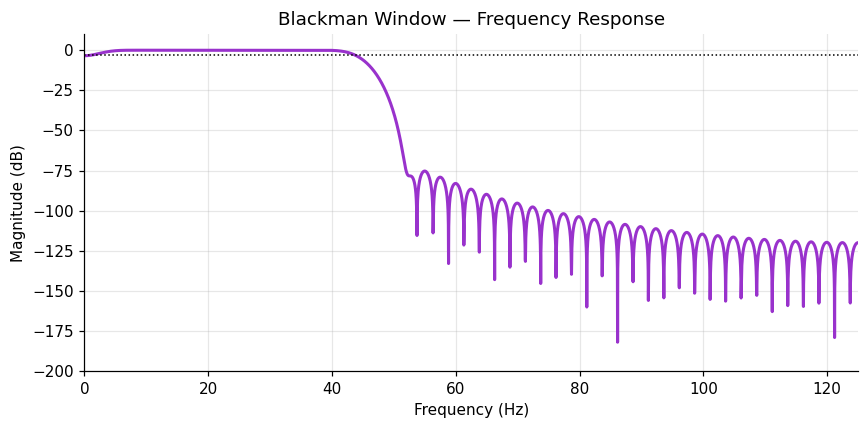

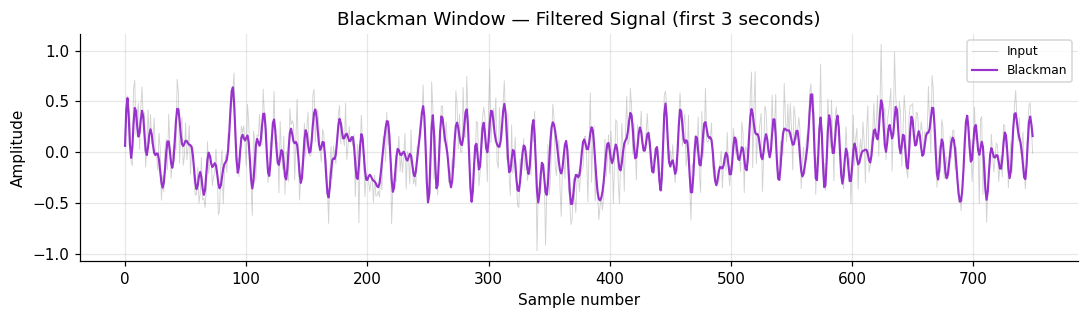

In [120]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLACKMAN WINDOW — FIR Band-Pass 1–45 Hz
# ═══════════════════════════════════════════════════════════════════════════════
# Blackman window = excellent stopband attenuation (very little ripple).
# Wider transition than Hann. Good when you need very clean stopband.

numtaps = 101
cutoff = [1.0/125, 45.0/125]  

# ── Design the filter ────────────────────────────────────────────────────────
taps = signal.firwin(numtaps, cutoff, pass_zero=False, window='blackman')

# ── Frequency response ───────────────────────────────────────────────────────
w, h = signal.freqz(taps, 1.0, worN=4096, fs=250)

plt.figure(figsize=(8, 4))
plt.plot(w, 20*np.log10(np.abs(h)+1e-12), lw=2, color='darkorchid')
plt.axhline(-3, color='black', ls=':', lw=1)
plt.xlim(0, 125)
plt.ylim(-200, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Blackman Window — Frequency Response")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Apply filter to signal ───────────────────────────────────────────────────
y_fir = signal.filtfilt(taps, 1.0, rest_dec)

plt.figure(figsize=(10, 3))
plt.plot(rest_dec[:750], lw=0.6, alpha=0.35, color='gray', label='Input')
plt.plot(y_fir[:750],    lw=1.4, color='darkorchid', label='Blackman')
plt.title("Blackman Window — Filtered Signal (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## SECTION 4: filtfilt vs lfilter + GUSTAFSSON EDGE METHOD

- lfilter, causal (real-time safe) but introduces phase delay: events appear shifted rightward in time → bad for connectivity.
- filtfilt: applies filter forward then backward → zero phase, 2× effective order.
- Gustafsson's method: chooses initial conditions so forward-backward and backward-forward passes agree → minimises edge artefacts.

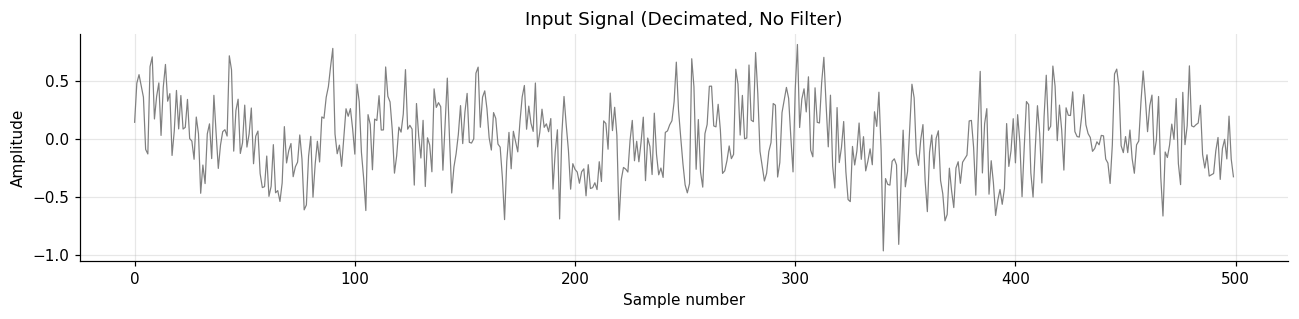

In [121]:
# ═══════════════════════════════════════════════════════════════════════════════
# INPUT SIGNAL — Raw (Decimated, No Filter)
# ═══════════════════════════════════════════════════════════════════════════════


plt.figure(figsize=(12, 3))
plt.plot(rest_dec[:500], lw=0.8, color='gray')
plt.title("Input Signal (Decimated, No Filter)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

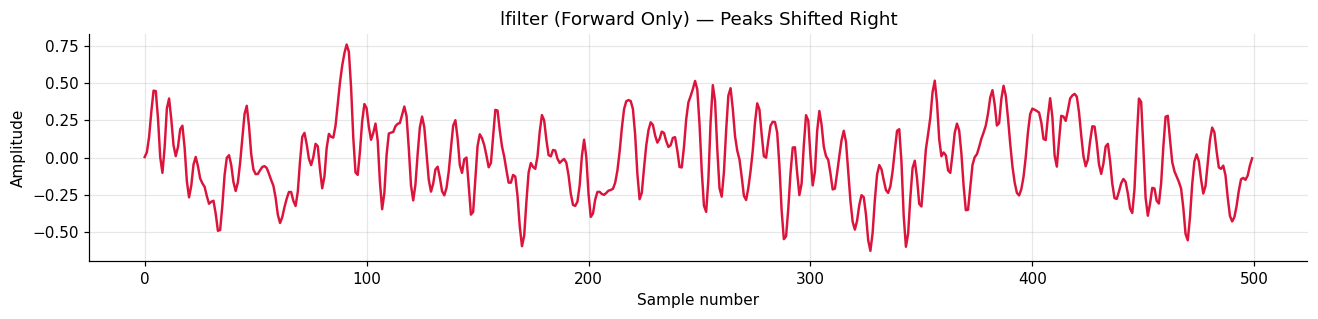

In [122]:
# ═══════════════════════════════════════════════════════════════════════════════
# lfilter — FORWARD ONLY (Causal)
# ═══════════════════════════════════════════════════════════════════════════════
# Applies the filter once, left to right. Peaks shift RIGHT (later in time).
# This is "real-time safe" but bad for EEG analysis — timing is wrong.

b, a = signal.butter(4, [1.0/125, 45.0/125], btype='band')
causal = signal.lfilter(b, a, rest_dec)

plt.figure(figsize=(12, 3))
plt.plot(causal[:500], lw=1.6, color='crimson')
plt.title("lfilter (Forward Only) — Peaks Shifted Right")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

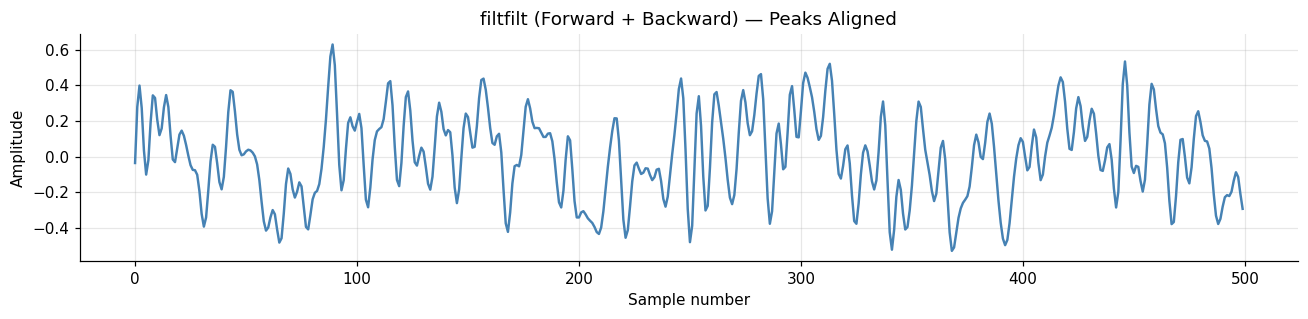

In [123]:
# ═══════════════════════════════════════════════════════════════════════════════
# filtfilt — FORWARD + BACKWARD (Zero-Phase)
# ═══════════════════════════════════════════════════════════════════════════════
# Applies the filter forward, then backward. The two delays cancel exactly.
# Peaks stay at the SAME time as the original signal. Use this for EEG.

b, a = signal.butter(4, [1.0/125, 45.0/125], btype='band')
zerophase = signal.filtfilt(b, a, rest_dec)

plt.figure(figsize=(12, 3))
plt.plot(zerophase[:500], lw=1.6, color='steelblue')
plt.title("filtfilt (Forward + Backward) — Peaks Aligned")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

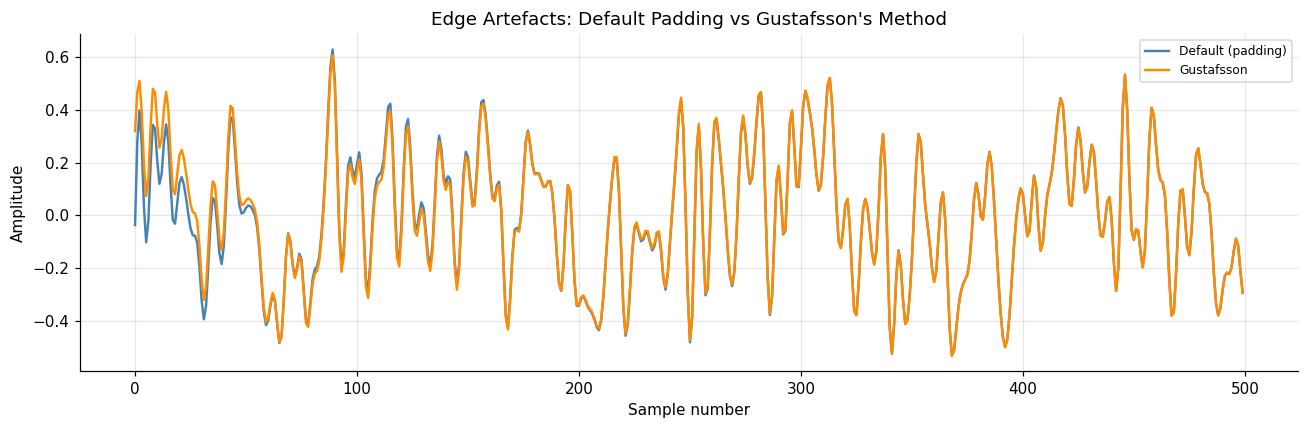

In [124]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEFAULT PADDING vs GUSTAFSSON METHOD
# ═══════════════════════════════════════════════════════════════════════════════
# filtfilt pads the signal edges before filtering (it needs past samples to start). 
# Gustafsson's method mathematically optimizes the initial conditions to minimize edge distortion.

# ── Apply with both methods ──────────────────────────────────────────────────
zerophase = signal.filtfilt(b, a, rest_dec)               # default (padding)
gust      = signal.filtfilt(b, a, rest_dec, method='gust') # Gustafsson

# ── Plot (first 2 seconds) ───────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(zerophase[:500], lw=1.6, color='steelblue',  label='Default (padding)')
plt.plot(gust[:500],      lw=1.6, color='darkorange', label='Gustafsson')
plt.title("Edge Artefacts: Default Padding vs Gustafsson's Method")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



> The two lines are nearly identical in the middle.
> Look at the very first samples (left edge). The default method shows a small "blip" or distortion at the start. Gustafsson's method minimizes this.
> For long recordings, the difference is tiny. For short segments, it matters.

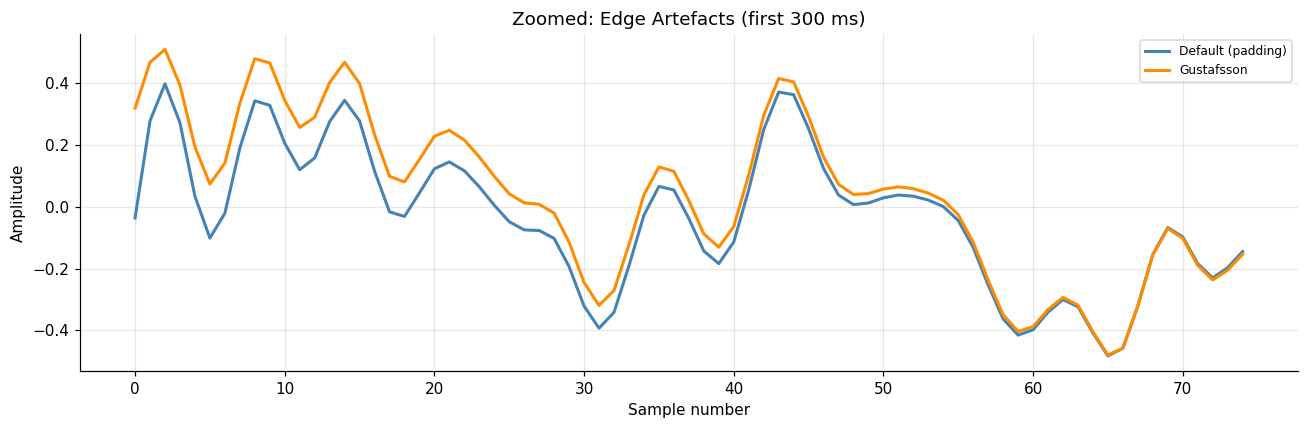

In [125]:
# ═══════════════════════════════════════════════════════════════════════════════
# EDGE ARTEFACTS — ZOOMED (first 75 samples = 300 ms)
# ═══════════════════════════════════════════════════════════════════════════════
# Zooming in on the very start makes edge artefacts visible.

plt.figure(figsize=(12, 4))
plt.plot(zerophase[:75], lw=2.0, color='steelblue',  label='Default (padding)')
plt.plot(gust[:75],      lw=2.0, color='darkorange', label='Gustafsson')
plt.title("Zoomed: Edge Artefacts (first 300 ms)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



> The first ~10-20 samples often show the biggest difference.
> Default padding can create a "ramp-up" artefact.
> Gustafsson's method minimizes this, starting closer to the true signal.
> For your tutorial, use method='gust' when filtering short segments.

## SECTION 5: NON-LINEAR FILTERING: MEDIAN & SAVITZKY-GOLAY

> ### Median filter:
> Best at removing impulsive noise while preserving edges.
> 
> ### Savitzky-Golay filter:
> Preserves peak heights and shapes better than a plain moving average.


In [126]:
# ═══════════════════════════════════════════════════════════════════════════════
# CREATE BAND-PASS FILTERED SIGNALS FOR THE REST OF THE TUTORIAL
# ═══════════════════════════════════════════════════════════════════════════════


nyq = 125
wn = [1.0/nyq, 45.0/nyq]

# Rest
sos = signal.butter(4, wn, btype='bandpass', output='sos')
rest_filt = signal.sosfiltfilt(sos, rest_dec)

# Move
sos = signal.butter(4, wn, btype='bandpass', output='sos')
move_filt = signal.sosfiltfilt(sos, move_dec)

print("Band-pass filtered signals created: rest_filt, move_filt")

Band-pass filtered signals created: rest_filt, move_filt


In [127]:
# ═══════════════════════════════════════════════════════════════════════════════
# CREATE NOISY SIGNAL — Inject Random Spikes
# ═══════════════════════════════════════════════════════════════════════════════
# Take the clean filtered signal and add 30 large random spikes.
# These simulate artefacts (eye blinks, muscle twitches, electrode pops).

rng = np.random.default_rng(42)                        # seed for reproducibility
rest_noisy = rest_filt.copy()                           # start with clean signal

spike_idx = rng.integers(50, len(rest_noisy)-50, size=30)  # 30 random positions
rest_noisy[spike_idx] += rng.choice([-1, 1], size=30) * rest_noisy.std() * 8
# Add ±8 standard deviations at each spike position → huge, visible spikes

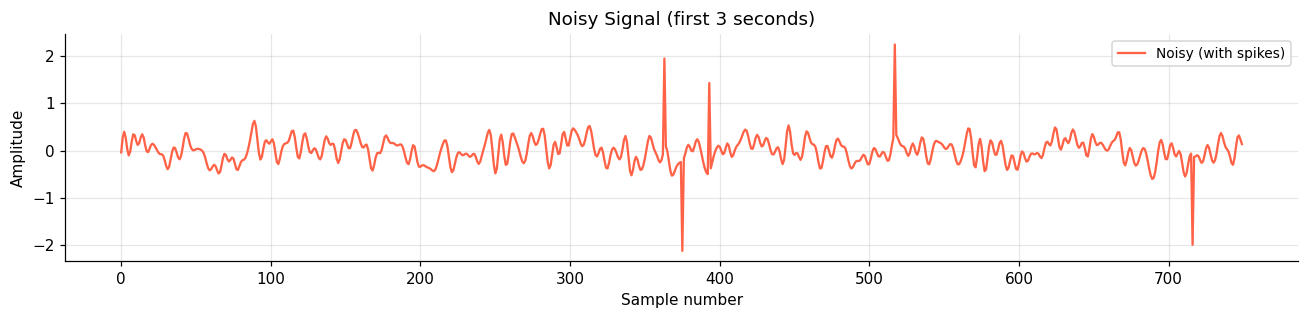

In [128]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOISY — See the injected spikes
# ═══════════════════════════════════════════════════════════════════════════════

plt.figure(figsize=(12, 3))
plt.plot(rest_noisy[:750], lw=1.5, color='tomato',    label='Noisy (with spikes)')
plt.title("Noisy Signal (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

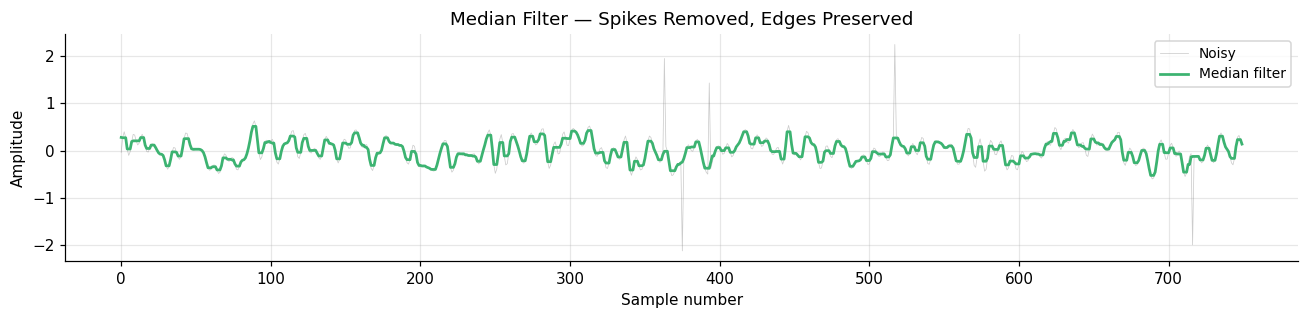

In [129]:
# ═══════════════════════════════════════════════════════════════════════════════
# MEDIAN FILTER — Spike Removal
# ═══════════════════════════════════════════════════════════════════════════════
# Median filter: at each sample, take the MEDIAN of 5 surrounding samples.
# Spikes are isolated extreme values — the median ignores them completely.
# Nonlinear → cannot be expressed as a weighted sum.

k_med = 5                                             # window = 5 samples = 20 ms
rest_median = median_filter(rest_noisy, size=k_med)    # apply median filter

plt.figure(figsize=(12, 3))
plt.plot(rest_noisy[:750],  lw=0.5, alpha=0.4, color='gray',  label='Noisy')
plt.plot(rest_median[:750], lw=1.8, color='mediumseagreen',   label='Median filter')
plt.title("Median Filter — Spikes Removed, Edges Preserved")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

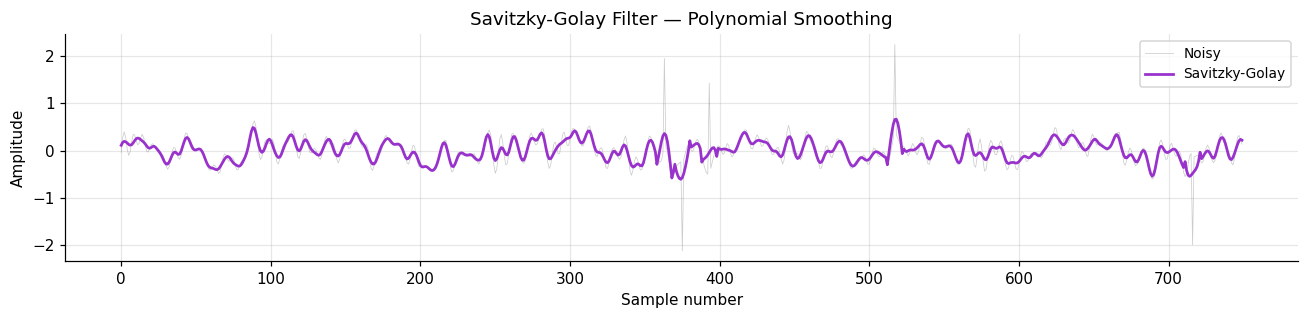

In [130]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVITZKY-GOLAY FILTER — Polynomial Smoothing
# ═══════════════════════════════════════════════════════════════════════════════
# Savitzky-Golay: fit a 3rd-degree polynomial to 11 samples around each point.
# Replace the center sample with the polynomial's value at the center.
# Preserves peak shapes better than a moving average.

rest_savgol = signal.savgol_filter(rest_noisy, window_length=11, polyorder=3)

plt.figure(figsize=(12, 3))
plt.plot(rest_noisy[:750],  lw=0.5, alpha=0.4, color='gray', label='Noisy')
plt.plot(rest_savgol[:750], lw=1.8, color='darkorchid',      label='Savitzky-Golay')
plt.title("Savitzky-Golay Filter — Polynomial Smoothing")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

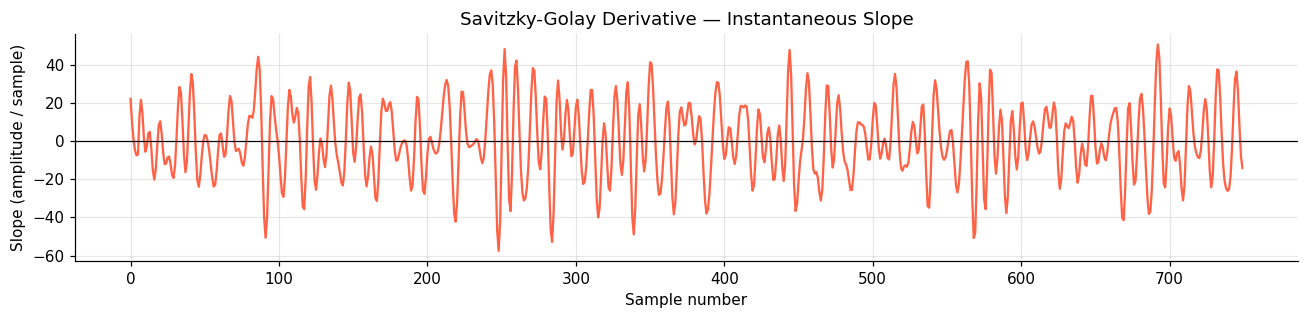

In [131]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVITZKY-GOLAY DERIVATIVE — Instantaneous Slope
# ═══════════════════════════════════════════════════════════════════════════════
# Same idea, but returns the 1st derivative (slope) instead of the smoothed value.
# Zero-crossings show where peaks and troughs are.
# Positive slope = signal rising. Negative slope = signal falling.

rest_sg_deriv = signal.savgol_filter(rest_filt, window_length=11, polyorder=3,
                                      deriv=1, delta=1/250)

plt.figure(figsize=(12, 3))
plt.plot(rest_sg_deriv[:750], lw=1.5, color='tomato')
plt.axhline(0, color='black', lw=0.8)
plt.title("Savitzky-Golay Derivative — Instantaneous Slope")
plt.xlabel("Sample number")
plt.ylabel("Slope (amplitude / sample)")
plt.tight_layout()
plt.show()

## SECTION 6: CONVOLUTION FOR TIME SERIES


> ### Window functions used as smoothing kernels:
> -   Box (rectangular):  equal weights, sharpest roll-off artefacts
> -   Hanning:            smooth bell, preferred for general smoothing
> -   Gaussian:           theoretically optimal for combined time/freq resolution

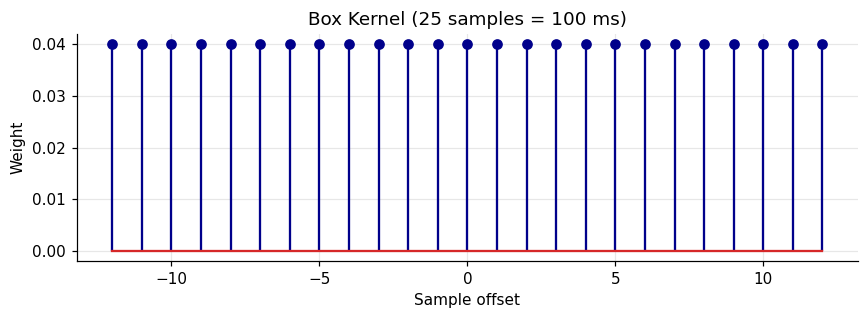

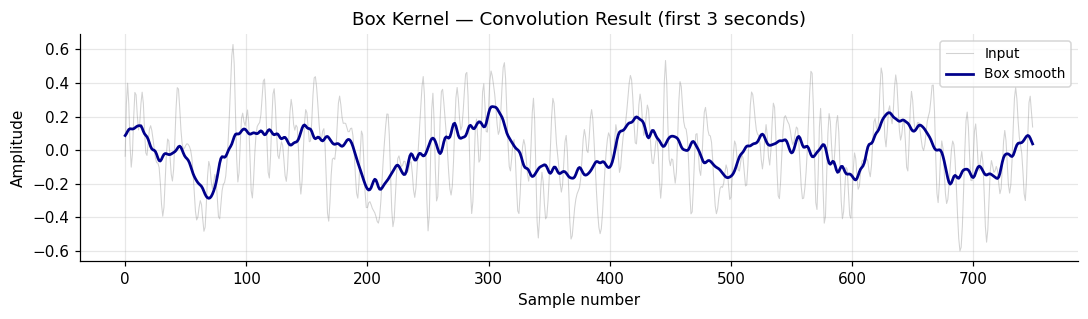

In [132]:
# ═══════════════════════════════════════════════════════════════════════════════
# BOX KERNEL — Moving Average (100 ms)
# ═══════════════════════════════════════════════════════════════════════════════
# A box kernel gives equal weight to all samples in the window.
# Simple but leaves "ringing" artefacts at sharp transitions.

N_box = 25                                            # 25 samples = 100 ms at 250 Hz
h_box = np.ones(N_box) / N_box                        # all weights = 1/25 = 0.04
y_box = signal.fftconvolve(rest_filt, h_box, mode='same')  # apply convolution

# ── Plot kernel ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.stem(np.arange(N_box) - N_box//2, h_box, linefmt='darkblue', markerfmt='darkblue')
plt.title("Box Kernel (25 samples = 100 ms)")
plt.xlabel("Sample offset")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

# ── Plot result ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(rest_filt[:750], lw=0.7, alpha=0.35, color='gray', label='Input')
plt.plot(y_box[:750],    lw=1.8, color='darkblue',        label='Box smooth')
plt.title("Box Kernel — Convolution Result (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

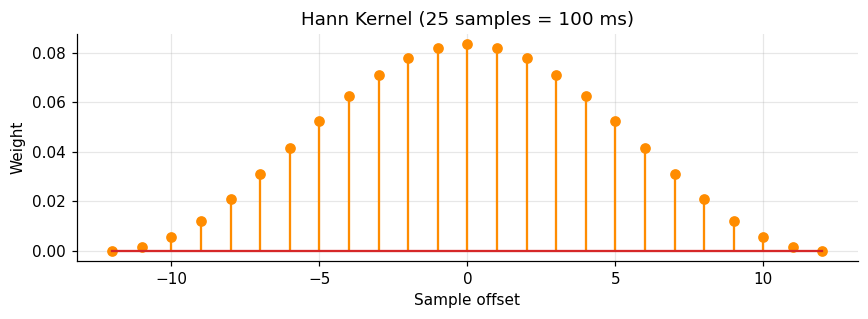

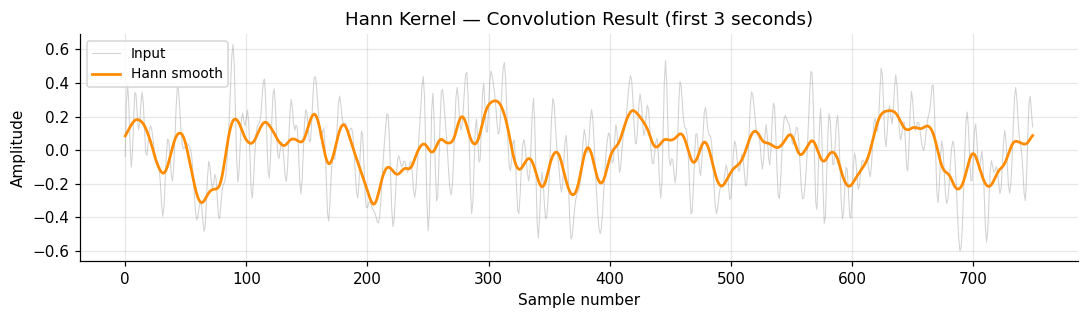

In [133]:
# ═══════════════════════════════════════════════════════════════════════════════
# HANN KERNEL — Smooth Bell-Shaped Weights (100 ms)
# ═══════════════════════════════════════════════════════════════════════════════
# A Hann window gives more weight to samples near the center.
# This reduces ringing artefacts compared to the box kernel.

h_hann = np.hanning(N_box)                             # Hann window values
h_hann /= h_hann.sum()                                 # normalize so sum = 1
y_hann = signal.fftconvolve(rest_filt, h_hann, mode='same')

# ── Plot kernel ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.stem(np.arange(N_box) - N_box//2, h_hann, linefmt='darkorange', markerfmt='darkorange')
plt.title("Hann Kernel (25 samples = 100 ms)")
plt.xlabel("Sample offset")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

# ── Plot result ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(rest_filt[:750], lw=0.7, alpha=0.35, color='gray', label='Input')
plt.plot(y_hann[:750],   lw=1.8, color='darkorange',      label='Hann smooth')
plt.title("Hann Kernel — Convolution Result (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

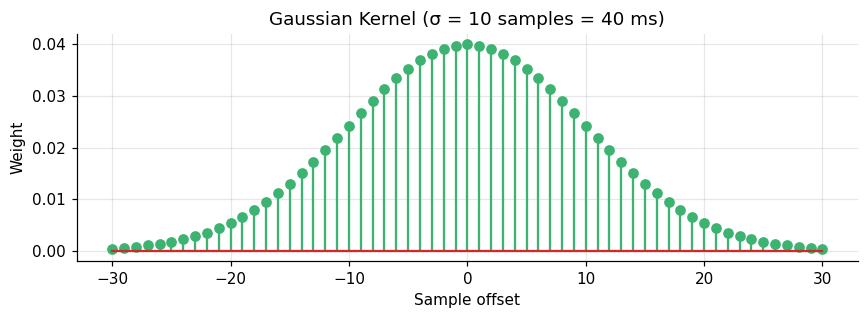

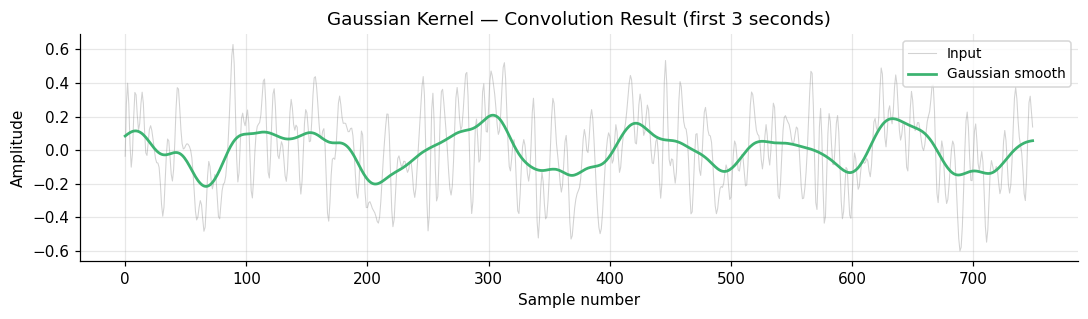

In [134]:
# ═══════════════════════════════════════════════════════════════════════════════
# GAUSSIAN KERNEL — Bell Curve (σ = 40 ms)
# ═══════════════════════════════════════════════════════════════════════════════
# A Gaussian gives smoothly decreasing weights. No abrupt cut-off.
# Theoretically optimal for combined time/frequency resolution.

sigma_s = 10                                           # σ = 10 samples = 40 ms
t_k = np.arange(-3*sigma_s, 3*sigma_s + 1)             # from -30 to +30 samples
h_gauss = np.exp(-0.5 * (t_k / sigma_s) ** 2)          # Gaussian bell curve
h_gauss /= h_gauss.sum()                               # normalize
y_gauss = signal.fftconvolve(rest_filt, h_gauss, mode='same')

# ── Plot kernel ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.stem(t_k, h_gauss, linefmt='mediumseagreen', markerfmt='mediumseagreen')
plt.title("Gaussian Kernel (σ = 10 samples = 40 ms)")
plt.xlabel("Sample offset")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

# ── Plot result ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(rest_filt[:750], lw=0.7, alpha=0.35, color='gray', label='Input')
plt.plot(y_gauss[:750],  lw=1.8, color='mediumseagreen',   label='Gaussian smooth')
plt.title("Gaussian Kernel — Convolution Result (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

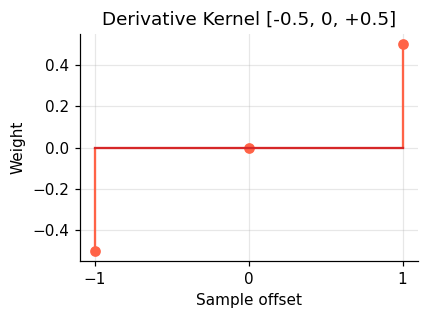

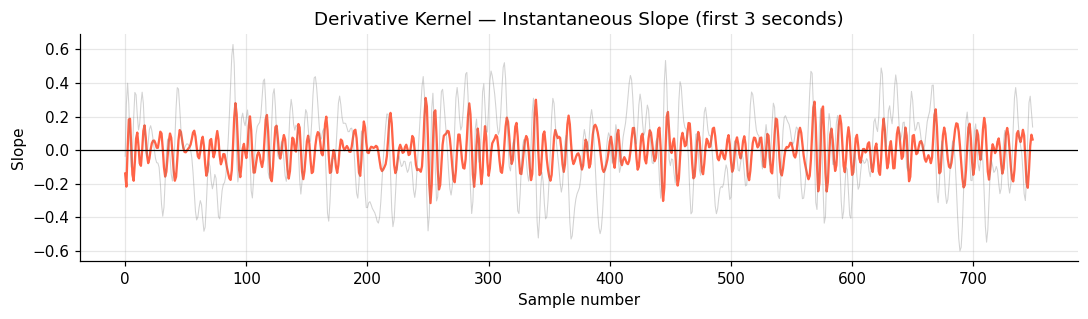

In [135]:
# ═══════════════════════════════════════════════════════════════════════════════
# DERIVATIVE KERNEL — Edge Detector (Slope)
# ═══════════════════════════════════════════════════════════════════════════════
# [ -0.5,  0,  +0.5 ] estimates the slope: (next sample - previous sample) / 2
# Positive output = signal rising. Negative = falling. Zero = flat or at a peak.

h_deriv = np.array([-0.5, 0.0, 0.5])                  # derivative kernel
y_deriv = signal.fftconvolve(rest_filt, h_deriv, mode='same')

# ── Plot kernel ──────────────────────────────────────────────────────────────
plt.figure(figsize=(4, 3))
plt.stem([-1, 0, 1], h_deriv, linefmt='tomato', markerfmt='tomato')
plt.title("Derivative Kernel [-0.5, 0, +0.5]")
plt.xlabel("Sample offset")
plt.ylabel("Weight")
plt.xticks([-1, 0, 1])
plt.tight_layout()
plt.show()

# ── Plot result ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(y_deriv[:750], lw=1.5, color='tomato')
plt.plot(rest_filt[:750], lw=0.7, alpha=0.35, color='gray', label='Input')
plt.axhline(0, color='black', lw=0.8)
plt.title("Derivative Kernel — Instantaneous Slope (first 3 seconds)")
plt.xlabel("Sample number")
plt.ylabel("Slope")
plt.tight_layout()
plt.show()

## SECTION 7: Z-SCORE NORMALISATION

> z[n] = (x[n] - μ) / σ

- Centres the signal at 0, scales variance to 1.
- Allows comparison of "relative modulation" across conditions/subjects.

- Do NOT z-score separately when absolute power differences matter.
-   Use percent-change or dB baseline normalisation instead.

In [136]:
# ═══════════════════════════════════════════════════════════════════════════════
# Z-SCORE FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════
# z = (x - mean) / standard_deviation
# After z-scoring: mean = 0, standard deviation = 1.
# This lets you compare "how many standard deviations from the mean" across
# different signals, even if they have different amplitudes.

def zscore(sig_in):
    mu = np.mean(sig_in)             # average of the signal
    sigma = np.std(sig_in)           # standard deviation (spread)
    if sigma < 1e-12:                # if signal is flat (no variation)
        return sig_in                # return unchanged (avoid division by zero)
    return (sig_in - mu) / sigma     # subtract mean, divide by std

In [149]:
# ═══════════════════════════════════════════════════════════════════════════════
# APPLY Z-SCORE TO BOTH CONDITIONS
# ═══════════════════════════════════════════════════════════════════════════════
rest_z = zscore(rest_filt)          # z-score band-passed rest
move_z = zscore(move_filt)          # z-score band-passed move

In [150]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK THE RESULTS
# ═══════════════════════════════════════════════════════════════════════════════
# After z-scoring: mean should be ~0, std should be ~1.
# Values > 3 or < -3 are potential outliers (more than 3 std from mean).

print("\n[Z-Score Results]")

# Rest
outliers_rest = (np.abs(rest_z) > 3).sum()
print(f"Rest:  mean={np.mean(rest_z):.2e}  std={np.std(rest_z):.4f}  "
      f"|z|>3: {outliers_rest}/{len(rest_z)}")

# Move
outliers_move = (np.abs(move_z) > 3).sum()
print(f"Move:  mean={np.mean(move_z):.2e}  std={np.std(move_z):.4f}  "
      f"|z|>3: {outliers_move}/{len(move_z)}")


[Z-Score Results]
Rest:  mean=-8.05e-18  std=1.0000  |z|>3: 16/3750
Move:  mean=-9.47e-18  std=1.0000  |z|>3: 6/3750


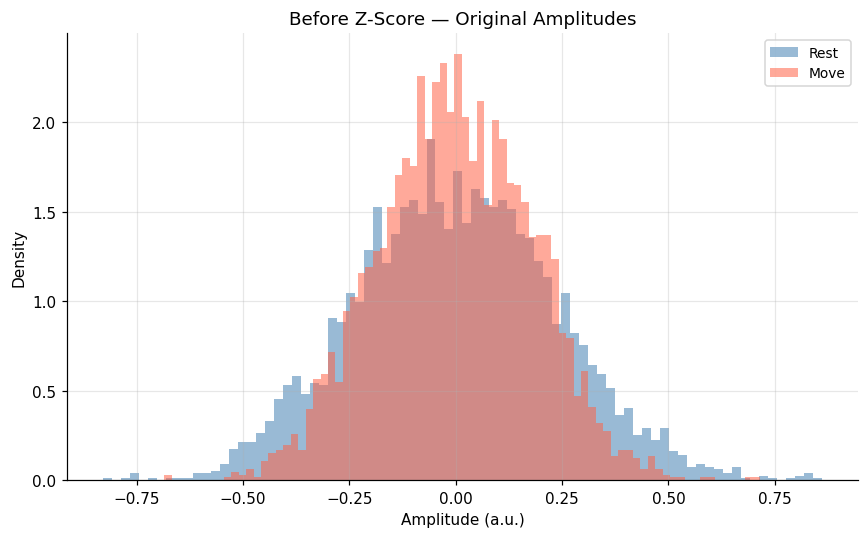

In [151]:
# ═══════════════════════════════════════════════════════════════════════════════
# HISTOGRAM — Before Z-Score (Original Amplitudes)
# ═══════════════════════════════════════════════════════════════════════════════
# Shows the distribution of amplitude values for Rest and Move.
# The means are near zero (band-passed data), but standard deviations may differ.

plt.figure(figsize=(8, 5))
plt.hist(rest_filt, bins=80, color='steelblue', alpha=0.55, density=True, label='Rest')
plt.hist(move_filt, bins=80, color='tomato',    alpha=0.55, density=True, label='Move')
plt.xlabel("Amplitude (a.u.)")
plt.ylabel("Density")
plt.title("Before Z-Score — Original Amplitudes")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

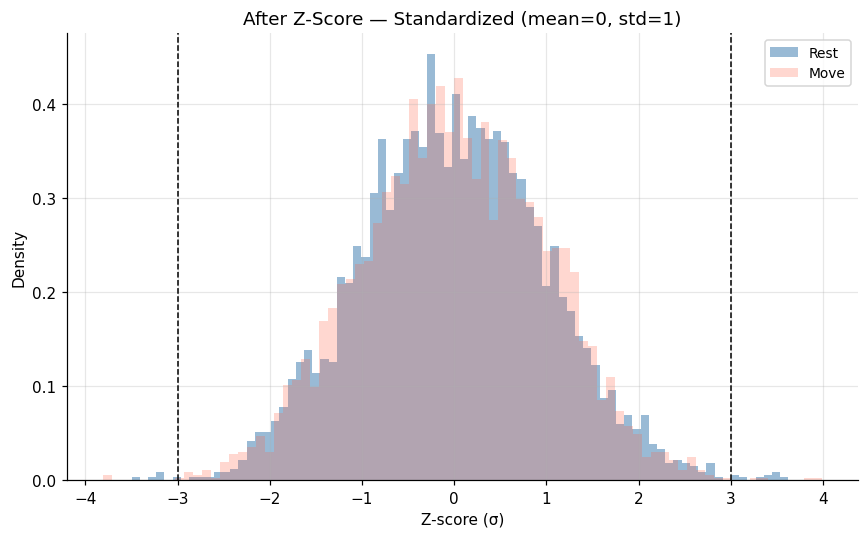

In [152]:
# ═══════════════════════════════════════════════════════════════════════════════
# HISTOGRAM — After Z-Score (Standardized)
# ═══════════════════════════════════════════════════════════════════════════════
# Both distributions now have mean=0 and std=1.
# The dashed lines at ±3 mark the "outlier" threshold.
# Rest and Move can now be compared in relative terms.

plt.figure(figsize=(8, 5))
plt.hist(rest_z, bins=80, color='steelblue', alpha=0.55, density=True, label='Rest')
plt.hist(move_z, bins=80, color='tomato',    alpha=0.25, density=True, label='Move')
plt.axvline(-3, color='black', ls='--', lw=1)
plt.axvline(3,  color='black', ls='--', lw=1)
plt.xlabel("Z-score (σ)")
plt.ylabel("Density")
plt.title("After Z-Score — Standardized (mean=0, std=1)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## SECTION 8: POWER SPECTRAL DENSITY (WELCH'S METHOD)

### Welch (1967):
1. Divide signal into overlapping windows of length L.
2. Apply window function (Hann) to reduce spectral leakage.
3. Compute |FFT|² per window.
4. Average → variance ↓ by ≈ number of windows.

 Frequency resolution:  Δf = fs / L
 nperseg = fs × 2  →  Δf = 0.5 Hz   (good for Beta sub-band separation)

### Expected neuro pattern at M1:
- Beta (13–30 Hz): dominant at rest, suppressed (ERD) during movement.

In [153]:
nperseg  = int(TARGET_FS * 2)   # 2-second windows
noverlap = nperseg // 2         # 50 % overlap

freqs_r, psd_rest = signal.welch(rest_z, TARGET_FS,
                                  nperseg=nperseg, noverlap=noverlap,
                                  window='hann', scaling='density')
freqs_m, psd_move = signal.welch(move_z, TARGET_FS,
                                  nperseg=nperseg, noverlap=noverlap,
                                  window='hann', scaling='density')

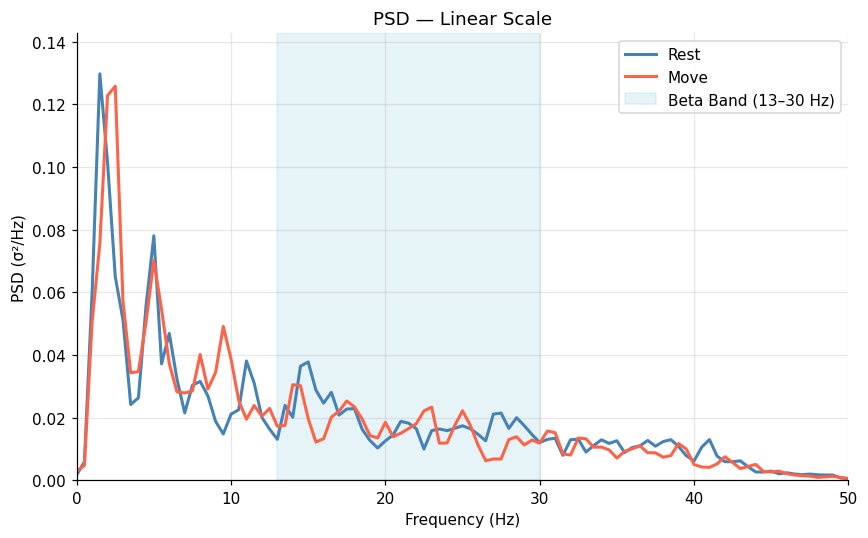

In [154]:
# Plot 1: Linear Scale
# Best for seeing the absolute magnitude of the dominant low frequencies
plt.figure(figsize=(8, 5))
plt.plot(freqs_r, psd_rest, color='steelblue', lw=2, label='Rest')
plt.plot(freqs_m, psd_move, color='tomato',    lw=2, label='Move')
plt.axvspan(13, 30, color='lightblue', alpha=0.30, label='Beta Band (13–30 Hz)')
plt.xlim(0, 50)
plt.ylim(0, np.max(psd_rest) * 1.1) # Auto-scale y-axis to fit the peak
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (σ²/Hz)")
plt.title("PSD — Linear Scale")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

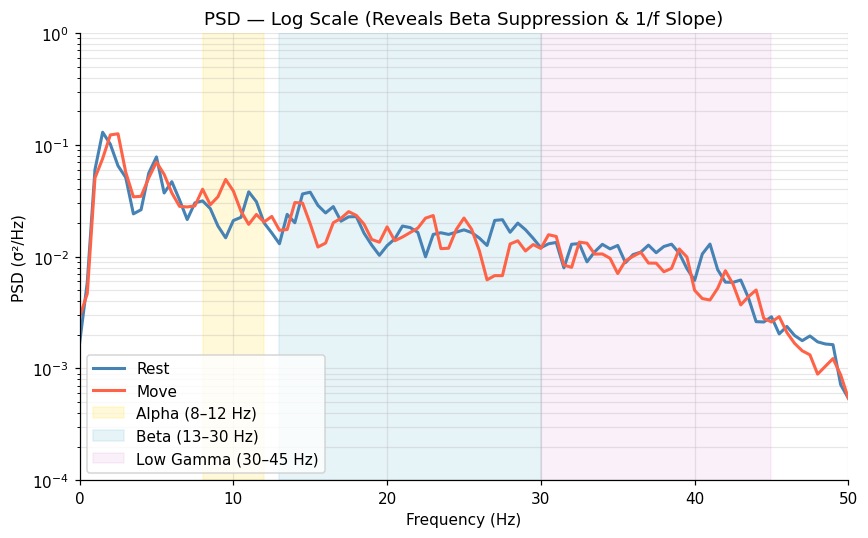

In [155]:
# Plot 2: Logarithmic Scale
# Best for visualizing the entire spectrum and identifying suppression across bands
plt.figure(figsize=(8, 5))
plt.semilogy(freqs_r, psd_rest, color='steelblue', lw=2, label='Rest')
plt.semilogy(freqs_m, psd_move, color='tomato',    lw=2, label='Move')
plt.axvspan( 8, 12, color='gold',      alpha=0.15, label='Alpha (8–12 Hz)')
plt.axvspan(13, 30, color='lightblue', alpha=0.30, label='Beta (13–30 Hz)')
plt.axvspan(30, 45, color='plum',      alpha=0.15, label='Low Gamma (30–45 Hz)')
plt.xlim(0, 50)
plt.ylim(1e-4, 1e-0) # Set fixed limits to show the "noise floor" vs "signal"
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (σ²/Hz)")
plt.title("PSD — Log Scale (Reveals Beta Suppression & 1/f Slope)")
plt.legend(loc='lower left') # Move legend to avoid obscuring the Beta drop
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## SECTION 9: SPECTROGRAM (TIME-FREQUENCY ANALYSIS)
 
### Why Spectrograms?
PSD averages power over the entire time series segment (15 seconds). It tells us *what* frequencies are present, but not *when*.
 
**Spectrograms** (Short-Time Fourier Transform) slides a window across the signal to show how frequency content evolves over time.
 
### The Trade-off:
 - **Wide Window**: Better Frequency Resolution, Worse Time Resolution.
 - **Narrow Window**: Better Time Resolution, Worse Frequency Resolution.
 
 > For Beta band (13-30Hz), we need at least ~1 second of data to resolve the frequency clearly.

In [156]:
from scipy.ndimage import gaussian_filter
from typing import Tuple, Optional

def smooth_spectrogram(Sxx: np.ndarray, sigma: Tuple[float, float] = (1.0, 1.0)) -> np.ndarray:
    """
    Apply 2D Gaussian smoothing to a spectrogram matrix (n_freqs, n_times).
    sigma = (freq_sigma, time_sigma) in units of bins.
    """
    if sigma is None:
        return Sxx
    return gaussian_filter(Sxx, sigma=sigma)

In [157]:
def plot_spectrogram(sig, fs, title):
    """
    Computes STFT, Smooths, and plots in dB scale with improved contrast.
    """
    nperseg = int(fs * 1.0)  # 1-second window
    noverlap = int(nperseg * 0.75) 
    
    f, t, Sxx = signal.spectrogram(sig, fs, nperseg=nperseg, noverlap=noverlap, window='hann')
    
    # Smooth the spectrogram
    Sxx_smooth = smooth_spectrogram(Sxx, sigma=(1.0, 2.0))
    
    # Convert to Decibels
    Sxx_db = 10 * np.log10(Sxx_smooth + 1e-12)
    
    # Set dynamic color limits to improve contrast
    # We set vmin to the 5th percentile to make the background darker, 
    # highlighting the active frequencies.
    vmin = np.percentile(Sxx_db, 70)
    vmax = np.percentile(Sxx_db, 99)
    
    plt.figure(figsize=(12, 6))
    # 'plasma' or 'inferno' often provides better visual contrast for dB scales than viridis
    mesh = plt.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='plasma', vmin=vmin, vmax=vmax)
    
    plt.ylim([12, 50])
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (sec)')
    plt.title(title)
    cbar = plt.colorbar(mesh, label='Power (dB)')
    plt.show()

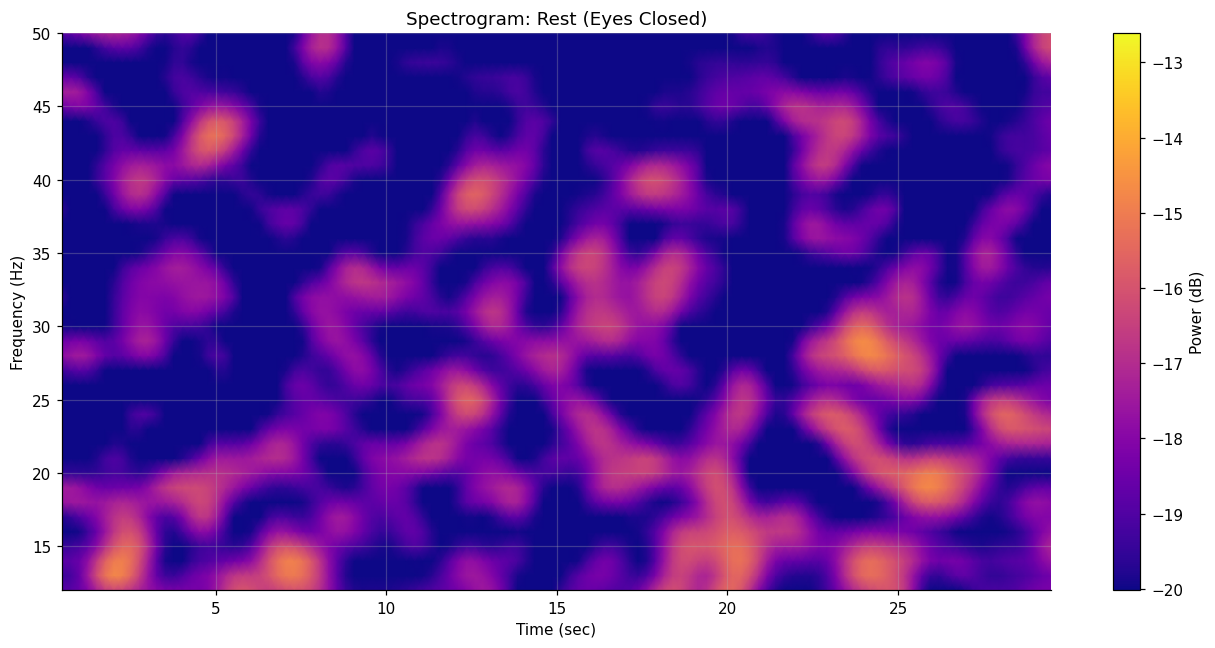

In [146]:
# Plot Rest Spectrogram
plot_spectrogram(rest_z, TARGET_FS, "Spectrogram: Rest (Eyes Closed)")

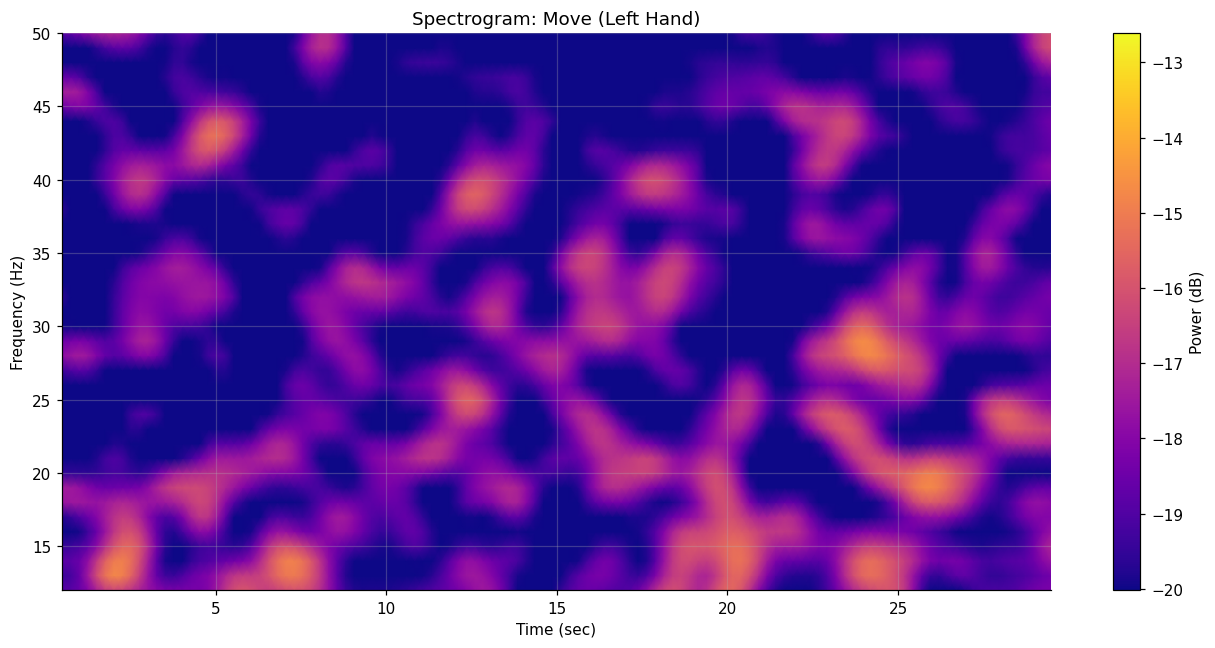

In [147]:
# Plot Move Spectrogram
plot_spectrogram(move_z, TARGET_FS, "Spectrogram: Move (Left Hand)")

### Differential Spectrogram (ERD Visualization)

**Event-Related Desynchronization (ERD)**, we can subtract the Rest spectrogram from the Move spectrogram.

- **Blue**: Power Decrease (Suppression/ERD)
- **Red**: Power Increase (Rebound/ERS)

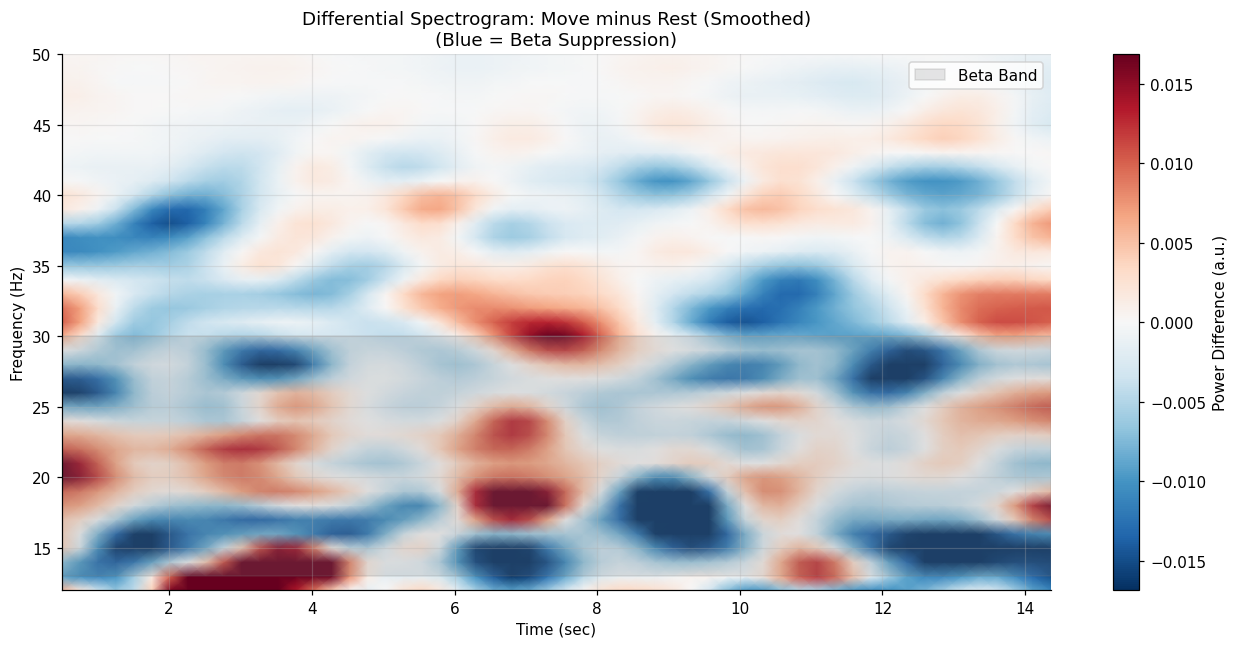

In [158]:
def plot_differential_spectrogram(sig_rest, sig_move, fs):
    nperseg = int(fs * 1.0)
    noverlap = int(nperseg * 0.75)
    
    # Compute Spectrograms
    f, t, Sxx_rest = signal.spectrogram(sig_rest, fs, nperseg=nperseg, noverlap=noverlap)
    _, _, Sxx_move = signal.spectrogram(sig_move, fs, nperseg=nperseg, noverlap=noverlap)
    
    # Calculate Difference (Move - Rest)
    Sxx_diff = Sxx_move - Sxx_rest
    
    # Apply 2D Gaussian Smoothing to the difference map
    # sigma=(1.0, 1.0) means 1 bin in freq, 1 bin in time
    Sxx_diff_smooth = smooth_spectrogram(Sxx_diff, sigma=(1.0, 2.0))
    
    plt.figure(figsize=(12, 6))
    # Use RdBu_r colormap for symmetric difference (Blue=Neg, Red=Pos)
    vmax = np.percentile(np.abs(Sxx_diff_smooth), 95)
    mesh = plt.pcolormesh(t, f, Sxx_diff_smooth, shading='gouraud', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    
    plt.ylim([12, 50])
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (sec)')
    plt.title("Differential Spectrogram: Move minus Rest (Smoothed)\n(Blue = Beta Suppression)")
    plt.colorbar(mesh, label='Power Difference (a.u.)')
    plt.axhspan(13, 30, color='gray', alpha=0.2, label='Beta Band')
    plt.legend(loc='upper right')
    plt.show()

plot_differential_spectrogram(rest_z, move_z, TARGET_FS)

